<a href="https://colab.research.google.com/github/huutai-cmyk/Homework-1/blob/main/baitapb1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#bai1
import folium
m= folium.Map(location=[10.762622, 106.660172], zoom_start=13)
folium.Marker([10.762622, 106.660172],popup='UEH A',tooltip='click vào').add_to(m)
m
places = [
    ["Bệnh viện Đại học Y Dược", 10.7553, 106.6640, "Bệnh viện"],
    ["Công viên Tao Đàn", 10.7798, 106.6916, "Công viên"],
    ["Nhà thờ Đức Bà", 10.7798, 106.6992, "Du lịch"],
    ["UBND Quận 1", 10.7765, 106.7011, "Cơ quan hành chính"],
    ["Bến xe Miền Đông", 10.8010, 106.7108, "Bến xe"]
]
place_layer = folium.FeatureGroup(name="Địa điểm công cộng")
for place in places:
    folium.Marker(
        location=[place[1], place[2]],
        popup=f"{place[0]} - {place[3]}",
        tooltip=place[0],
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(place_layer)

place_layer.add_to(m)
folium.LayerControl().add_to(m)
m


In [9]:
#bai2
import folium
from geopy.distance import geodesic
import itertools
centre = (10.749146670860188, 106.62457891729468)
places= {
    'place1':(10.743430688039325, 106.63917499413571),
    'place2':(10.743530969372314, 106.63509217543894),
    'place3':(10.7625838180305, 106.57150227423632),
    'place4': (10.76288464283105, 106.56762359647435),
    'place5':(10.762406170071703, 106.67316416050205),
    'place6:':(10.75845318133773, 106.6717026224287),
    'place7':(10.755715001136878, 106.67362350407672),
    'place8':(10.769396064226337, 106.67162794053057),
    'place9':(10.765601686830989, 106.67787212311599)
}
m= folium.Map(location=centre,zoom_start=13)
folium.Marker(location=centre, icon=folium.Icon(color='orange')).add_to(m)
for name, coord in places.items():
  dist= geodesic (centre, coord).km
  folium.Marker(location=coord,popup=f'{name}:{dist:.2f}km',icon=folium.Icon(color='red')).add_to(m)
  folium.PolyLine(locations=[centre,coord],tooltip=f'{dist:.2f}km', color='blue',weight=5 ).add_to(m)
all_points = [centre] + list(places.values())
m.fit_bounds(all_points)
distance={name:geodesic(centre,coord).km for name, coord in places.items()}
print('khoảng cách từ mỗi điểm đến diểm trung tâm:')
for name,dist in distance.items():
  print(f'{name}:{dist:2f}km')
m

khoảng cách từ mỗi điểm đến diểm trung tâm:
place1:1.717156km
place2:1.306986km
place3:5.992587km
place4:6.412233km
place5:5.512770km
place6::5.256055km
place7:5.413363km
place8:5.612328km
place9:6.106561km


In [10]:
#bai3
import folium
from folium.plugins import HeatMap
m= folium.Map(location=[10.749146670860188, 106.62457891729468],zoom_start=13)
heat_data=[[10.743430688039325, 106.63917499413571],[10.743530969372314, 106.63509217543894],
        [10.7625838180305, 106.57150227423632],[10.762406170071703, 106.67316416050205],
        [10.75845318133773, 106.6717026224287]]
HeatMap(heat_data).add_to(m)
m

In [ ]:
#bai5
import folium
centre= {
    'kho A':[10.759430010542882, 106.670868547314],
    'kho B':[10.761638723011927, 106.66707749755365],
    'kho C':[10.756400226697835, 106.66352625295288]
}
m=folium.Map(location=[10.761525981172412, 106.66896883015208],zoom_start=13 )
for name, loc in centre.items():
  folium.Marker(loc,popup = name, icon=folium.Icon(color='yellow')).add_to(m)
  folium.Circle(loc,radius=400, color='yellow',fill=True,fill_opacity=0.5  ).add_to(m)
m

/tmp/ipykernel_7176/3245117038.py:9: UserWarning: color argument of Icon should be one of: {'purple', 'darkblue', 'lightblue', 'darkred', 'darkgreen', 'black', 'white', 'lightred', 'darkpurple', 'lightgreen', 'beige', 'orange', 'green', 'gray', 'pink', 'blue', 'lightgray', 'red', 'cadetblue'}.
  folium.Marker(loc,popup = name, icon=folium.Icon(color='yellow')).add_to(m)


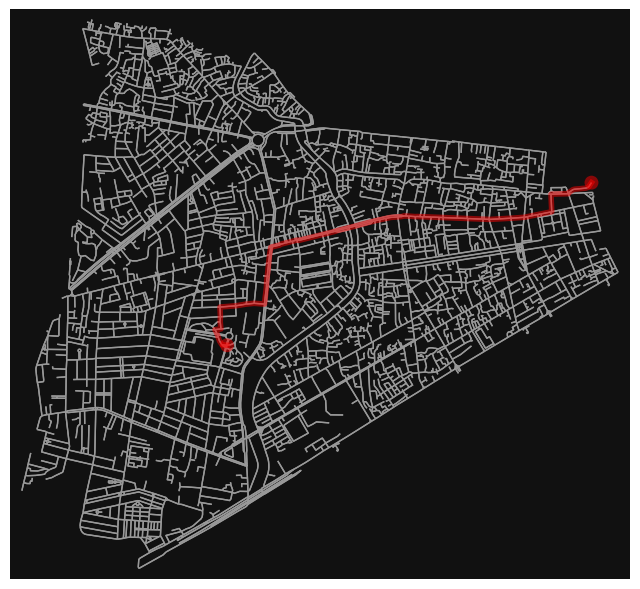

In [ ]:
#bai6
!pip install osmnx
import osmnx as ox
import networkx as nx
ox.log_console = True
ox.use_cache = True
place='district 6, Ho Chi Minh City, Viet Nam'
G_walk = ox.graph_from_place(place, network_type='walk')
origin_coords = ox.geocode('Binh Phu park, Ho Chi Minh City, Viet Nam')
destination_coords = ox.geocode('Sai Gon centre, Ho Chi Minh City, Viet Nam')
orig_node = ox.distance.nearest_nodes(G_walk, origin_coords[1], origin_coords[0])
dest_node = ox.distance.nearest_nodes(G_walk, destination_coords[1], destination_coords[0])
route = nx.shortest_path(G_walk, orig_node, dest_node, weight='length')
fig,ax = ox.plot_graph_route(G_walk, route, node_size=0)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.2 MB/s eta 0:00:00
Chạy thuật toán Dijkstra
Thời gian chạy Dijkstra: 0.00296 giây
Chạy thuật toán A*
Thời gian chạy A*: 0.00301 giây
Cả 2 đều tìm ra 1 đường tối ưu nhất


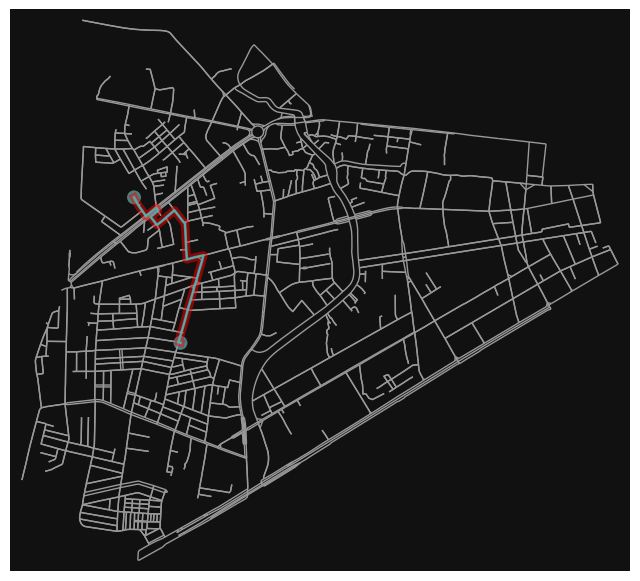

In [12]:
#bai7
!pip install osmnx
import osmnx as ox
import networkx as nx
import time
import math

place='district 6, Ho Chi Minh City, Viet Nam'
G = ox.graph_from_place(place, network_type='drive')

A_point = (10.742425122460123, 106.63046281923194)
B_point = (10.750457115641641, 106.62739437197054)

A_node = ox.distance.nearest_nodes(G, X=A_point[1],Y=A_point[0])
B_node = ox.distance.nearest_nodes(G, X=B_point[1],Y=B_point[0])

print('Chạy thuật toán Dijkstra')
start_time_dijkstra = time.time()
route_dijkstra = nx.shortest_path(G, A_node, B_node, weight='length', method='dijkstra')
end_time_dijkstra = time.time()
print(f'Thời gian chạy Dijkstra: {end_time_dijkstra - start_time_dijkstra:.5f} giây')

print('Chạy thuật toán A*')
def thuattoan_A (node1, node2):
  x1, y1 = G.nodes[node1]['x'], G.nodes[node1]['y']
  x2, y2 = G.nodes[node2]['x'], G.nodes[node2]['y']
  return math.sqrt((x1 - x2)**2 + (y1 - y2)**2) * 111000

start_time_astar = time.time()
route_astar = nx.astar_path(G, A_node, B_node, heuristic=thuattoan_A, weight='length')
end_time_astar = time.time()
print(f'Thời gian chạy A*: {end_time_astar - start_time_astar:.5f} giây')

if route_dijkstra == route_astar:
  print('Cả 2 đều tìm ra 1 đường tối ưu nhất')

fig, ax = ox.plot_graph_routes(
    G,
    routes=[route_dijkstra, route_astar],
    route_colors=['red', 'cyan'],
    route_linewidths=[6, 2],
    node_size=0,
    show=True
)